# Setup

## 1. Create the conda/mamba environment
This notebook needs a geospatial Python stack (GDAL, rasterio, rioxarray, earthaccess,
etc.) that's much easier to manage with conda/mamba than plain pip/venv.

From the repo root, in a terminal:
```
mamba env create -f environment.yml
mamba activate emit-fcov
```
Already have the `emit-fcov` env and just pulled changes to `environment.yml`?
```
mamba env update -n emit-fcov -f environment.yml --prune
```
Then point this notebook's kernel at the `emit-fcov` env (kernel picker in the notebook
toolbar). **If imports fail right after creating/updating the env, restart the kernel** —
a running kernel process won't pick up newly installed/changed packages on its own.

## 2. NASA Earthdata credentials
`earthaccess.login()` below needs an Earthdata Login account. Either let it prompt you
interactively the first time (`earthaccess.login(persist=True)` saves the result to
`~/.netrc` so you won't be asked again), or set `EARTHDATA_USERNAME` /
`EARTHDATA_PASSWORD` env vars yourself. No account? Register free at
https://urs.earthdata.nasa.gov/.

## 3. What this notebook does
1. Searches NASA Earthdata (CMR) for EMIT L2B Fractional Cover granules over a bounding
   box + date range — edit `bbox` / `temporal` in the Search cell to point at a
   different region/time.
2. Downloads every matching granule's 7 GeoTIFFs (PV/NPV/BARE fraction, their 3
   uncertainty bands, 1 QC band).
3. Applies the QC band as a mask (drops cloud/urban/water/snow-ice pixels) uniformly
   across the fraction + uncertainty bands.
4. Mosaics every granule the search found into one continuous scene and visualizes it.
5. Exports the mosaic as analysis-ready GeoTIFFs.

## 4. Reference docs
- EMIT L2B Fractional Cover User Guide: https://github.com/emit-sds/emit-sds-frcov/blob/main/docs/EMIT_L2B_Fractional_Cover_User_Guide.md
- QC flag integer codes used below were reverse-engineered from
  `singleband_raster_hierarchy()` in `create_frcov_masks.py` at
  https://github.com/emit-sds/emit-sds-frcov — the User Guide names the flag
  categories (cloud, urban, water, snow/ice) but doesn't publish the codes. If EMIT-SDS
  ever formalizes these in the ATBD itself, prefer that over this notebook's values.

# EMIT Fracitonal Cover Analysis

In [11]:
# Import Libraries
import earthaccess
import numpy as np
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [ ]:
# QC flag codes -- from singleband_raster_hierarchy() in create_frcov_masks.py,
# https://github.com/emit-sds/emit-sds-frcov (not formally published in the User Guide).
# Hierarchical: each pixel gets the FIRST condition below that applies to it.
flag_labels = {
    0: "clear",
    1: "cloud_or_cirrus",
    2: "urban",
    3: "water_or_coastal",
    4: "snow_ice",
}  # -9999 = nodata (outside scene footprint); handled separately via masked=True on load

flag_colors = ["#2ca02c", "#7f7f7f", "#d62728", "#1f77b4", "#f2f2f2"]
cmap = ListedColormap(flag_colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

In [12]:
# Authenticate with NASA Earthdata (reads ~/.netrc, or prompts + persists on first run)
auth = earthaccess.login(persist=True)

In [ ]:
# Search

Edit `bbox` (lon_min, lat_min, lon_max, lat_max) and `temporal` below to point this at a
different region or date range. `concept_id` identifies the EMIT L2B Fractional Cover &
Uncertainty (60 m, V001) collection specifically — leave that as-is unless you want a
different EMIT product.

In [13]:
# Search: EMIT L2B Fractional Cover & Uncertainty (60 m, V001) over Maui,
# one-month buffer around the 2025-08-17 acquisition (G3991818701-LPCLOUD)
bbox = (-156.74918, 20.47418, -155.83513, 21.09401)  # (lon_min, lat_min, lon_max, lat_max)
temporal = ("2025-08-16", "2025-08-18")

results = earthaccess.search_data(
    concept_id="C3911089796-LPCLOUD",  # EMIT_L2BFRCOV.001 collection (LPCLOUD)
    bounding_box=bbox,
    temporal=temporal,
)

print(f"Found {len(results)} granule(s)")

Found 2 granule(s)


/Users/kluis/miniforge3/envs/emit-fcov/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [14]:
# Print every file (granule ID + all associated data/browse links) found in the search
for granule in results:
    print(granule["meta"]["native-id"])
    for link in granule.data_links():
        print(f"  {link}")

EMIT_L2B_FRCOV_001_20250817T233321_2522915_004
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVQC_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVPV_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVPVUNC_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVNPV_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVNPVUNC_001_20250817T233321_2522915_004.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-p

In [16]:
# Download the granule matching the original EDSC link (G3991818701-LPCLOUD)
import os

selected_id = "EMIT_L2B_FRCOV_001_20250817T233321_2522915_004"
selected_granule = next(g for g in results if g["meta"]["native-id"] == selected_id)

data_dir = os.path.join("data", "emit_fcov", selected_id)
os.makedirs(data_dir, exist_ok=True)

downloaded_files = earthaccess.download([selected_granule], local_path=data_dir)

print(f"Downloaded {len(downloaded_files)} file(s) to {data_dir}")
for f in downloaded_files:
    print(f"  {f}")

QUEUEING TASKS | : 100%|██████████| 7/7 [00:00<00:00, 4629.47it/s]
PROCESSING TASKS | : 100%|██████████| 7/7 [00:00<00:00, 97541.95it/s]
COLLECTING RESULTS | : 100%|██████████| 7/7 [00:00<00:00, 184654.89it/s]

Downloaded 7 file(s) to data/emit_fcov/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004
  data/emit_fcov/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVQC_001_20250817T233321_2522915_004.tif
  data/emit_fcov/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVPV_001_20250817T233321_2522915_004.tif
  data/emit_fcov/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVPVUNC_001_20250817T233321_2522915_004.tif
  data/emit_fcov/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVNPV_001_20250817T233321_2522915_004.tif
  data/emit_fcov/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVNPVUNC_001_20250817T233321_2522915_004.tif
  data/emit_fcov/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVBARE_001_20250817T233321_2522915_004.tif
  data/emit_fcov/EMIT_L2B_FRCOV_001_20250817T233321_2522915_004/EMIT_L2B_FRCOVBAREUNC_001_20250817T233321_2522915_004.tif


# Open & Reconcile: QC Flags + Uncertainty + Fractional Cover

The 7 GeoTIFFs share one grid (same CRS/transform/shape), so we can load them
into a single `xarray.Dataset` and apply the QC band as a mask across the
fraction (PV/NPV/BARE) and uncertainty bands consistently, rather than
treating each file in isolation.

QC flag values (from `create_frcov_masks.py` in the ATBD repo):
`0` clear · `1` cloud/cirrus · `2` urban · `3` water/coastal · `4` snow/ice · `-9999` nodata.

In [17]:
# Match each downloaded file to its band role (check *UNC variants before their base name)
band_files = {}
for f in downloaded_files:
    name = os.path.basename(f)
    if "FRCOVQC" in name:
        band_files["qc"] = f
    elif "FRCOVPVUNC" in name:
        band_files["pv_unc"] = f
    elif "FRCOVNPVUNC" in name:
        band_files["npv_unc"] = f
    elif "FRCOVBAREUNC" in name:
        band_files["bare_unc"] = f
    elif "FRCOVPV" in name:
        band_files["pv"] = f
    elif "FRCOVNPV" in name:
        band_files["npv"] = f
    elif "FRCOVBARE" in name:
        band_files["bare"] = f

assert len(band_files) == 7, f"Expected 7 bands, matched {len(band_files)}: {band_files}"

# masked=True turns each band's nodata fill (-9999) into NaN on load
ds = xr.Dataset(
    {role: rxr.open_rasterio(path, masked=True).squeeze("band", drop=True)
     for role, path in band_files.items()}
)

shapes = {role: da.shape for role, da in ds.data_vars.items()}
assert len(set(shapes.values())) == 1, f"Grid mismatch across bands: {shapes}"

print(ds)

<xarray.Dataset> Size: 204MB
Dimensions:      (x: 1928, y: 2033)
Coordinates:
  * x            (x) float64 15kB -157.1 -157.1 -157.1 ... -156.0 -156.0 -156.0
  * y            (y) float64 16kB 21.37 21.37 21.37 21.37 ... 20.27 20.27 20.27
    spatial_ref  int64 8B 0
Data variables:
    qc           (y, x) float32 16MB ...
    pv           (y, x) float64 31MB ...
    pv_unc       (y, x) float64 31MB ...
    npv          (y, x) float64 31MB ...
    npv_unc      (y, x) float64 31MB ...
    bare         (y, x) float64 31MB ...
    bare_unc     (y, x) float64 31MB ...


In [18]:
# Reconcile: apply the QC mask uniformly to every fraction + uncertainty band,
# then sanity-check that PV + NPV + BARE ~= 1 on the surviving (clear) pixels.
flag_labels = {0: "clear", 1: "cloud_or_cirrus", 2: "urban", 3: "water_or_coastal", 4: "snow_ice"}
value_vars = ["pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]

clear = ds["qc"] == 0  # keep only unflagged, retrieval-valid land pixels

ds_clear = ds.copy()
for v in value_vars:
    ds_clear[v] = ds[v].where(clear)

frac_sum = ds_clear["pv"] + ds_clear["npv"] + ds_clear["bare"]
print(f"PV+NPV+BARE on clear pixels -> mean: {float(frac_sum.mean(skipna=True)):.4f}, "
      f"std: {float(frac_sum.std(skipna=True)):.4f} (should be ~1.0 / ~0)")

total = int(ds["qc"].notnull().sum())
print(f"\nQC flag breakdown ({total} pixels with valid geometry):")
for code, label in flag_labels.items():
    n = int((ds["qc"] == code).sum())
    print(f"  {code} {label:16s}: {n:8d}  ({100 * n / total:5.1f}%)")

PV+NPV+BARE on clear pixels -> mean: 1.0000, std: 0.0000 (should be ~1.0 / ~0)

QC flag breakdown (1966749 pixels with valid geometry):
  0 clear           :   376214  ( 19.1%)
  1 cloud_or_cirrus :   500906  ( 25.5%)
  2 urban           :     9979  (  0.5%)
  3 water_or_coastal:  1079131  ( 54.9%)
  4 snow_ice        :      519  (  0.0%)


# Visualize: QC Flags + Fractional Cover Composite

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


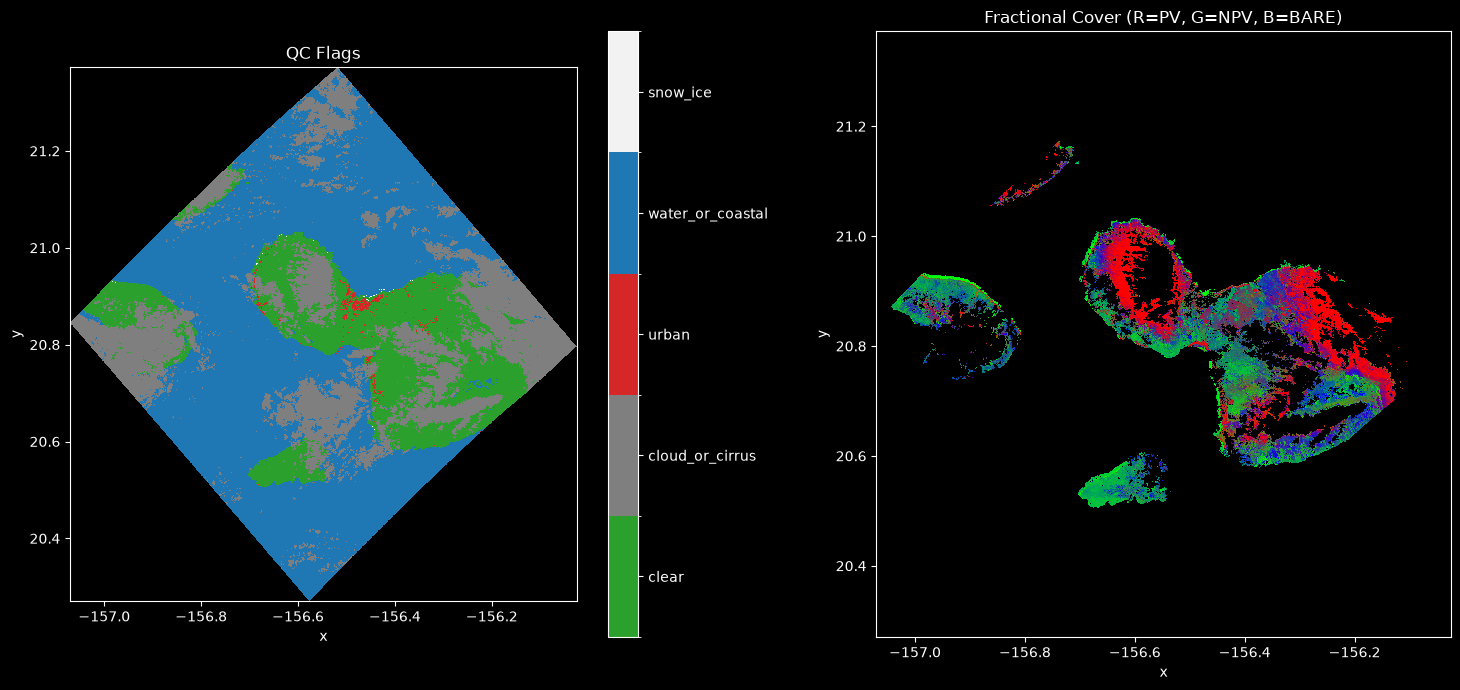

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# --- QC flag map ---
flag_colors = ["#2ca02c", "#7f7f7f", "#d62728", "#1f77b4", "#f2f2f2"]  # clear, cloud, urban, water, snow/ice
cmap = ListedColormap(flag_colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

im0 = ds["qc"].plot.imshow(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
axes[0].set_title("QC Flags")
axes[0].set_aspect("equal")
cbar = fig.colorbar(im0, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(list(flag_labels.values()))

# --- RGB fractional cover composite (clear pixels only; masked pixels -> black) ---
rgb = xr.concat(
    [ds_clear["pv"].fillna(0), ds_clear["npv"].fillna(0), ds_clear["bare"].fillna(0)],
    dim="band",
).transpose("y", "x", "band")

rgb.plot.imshow(ax=axes[1], rgb="band")
axes[1].set_title("Fractional Cover (R=PV, G=NPV, B=BARE)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

# Mosaic Adjacent Scenes (004 + 005)

Same orbit, ~12 seconds apart — likely tiling strips across Maui. Reuse the
download-and-reconcile steps as a function, run it for scene 005, then merge
both QC-masked datasets into one continuous mosaic.

In [20]:
def download_and_reconcile(granule):
    """Download a granule's 7 GeoTIFFs, load into one aligned Dataset, mask
    fraction + uncertainty bands to QC-clear pixels. Returns (ds, ds_clear)."""
    granule_id = granule["meta"]["native-id"]
    out_dir = os.path.join("data", "emit_fcov", granule_id)
    os.makedirs(out_dir, exist_ok=True)
    files = earthaccess.download([granule], local_path=out_dir)

    roles = {}
    for f in files:
        name = os.path.basename(f)
        if "FRCOVQC" in name:
            roles["qc"] = f
        elif "FRCOVPVUNC" in name:
            roles["pv_unc"] = f
        elif "FRCOVNPVUNC" in name:
            roles["npv_unc"] = f
        elif "FRCOVBAREUNC" in name:
            roles["bare_unc"] = f
        elif "FRCOVPV" in name:
            roles["pv"] = f
        elif "FRCOVNPV" in name:
            roles["npv"] = f
        elif "FRCOVBARE" in name:
            roles["bare"] = f
    assert len(roles) == 7, f"Expected 7 bands, matched {len(roles)}: {roles}"

    g_ds = xr.Dataset(
        {role: rxr.open_rasterio(path, masked=True).squeeze("band", drop=True)
         for role, path in roles.items()}
    )

    clear = g_ds["qc"] == 0
    g_ds_clear = g_ds.copy()
    for v in ["pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]:
        g_ds_clear[v] = g_ds[v].where(clear)

    return g_ds, g_ds_clear


selected_id_005 = "EMIT_L2B_FRCOV_001_20250817T233333_2522915_005"
granule_005 = next(g for g in results if g["meta"]["native-id"] == selected_id_005)

ds_005, ds_005_clear = download_and_reconcile(granule_005)
print(ds_005)

/Users/kluis/miniforge3/envs/emit-fcov/lib/python3.12/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 7/7 [00:00<00:00, 989.96it/s]
PROCESSING TASKS | : 100%|██████████| 7/7 [00:02<00:00,  2.45it/s]
COLLECTING RESULTS | : 100%|██████████| 7/7 [00:00<00:00, 120823.57it/s]


<xarray.Dataset> Size: 203MB
Dimensions:      (x: 1919, y: 2033)
Coordinates:
  * x            (x) float64 15kB -156.6 -156.6 -156.6 ... -155.5 -155.5 -155.5
  * y            (y) float64 16kB 20.8 20.8 20.8 20.79 ... 19.7 19.7 19.69 19.69
    spatial_ref  int64 8B 0
Data variables:
    qc           (y, x) float32 16MB nan nan nan nan nan ... nan nan nan nan nan
    pv           (y, x) float64 31MB ...
    pv_unc       (y, x) float64 31MB ...
    npv          (y, x) float64 31MB ...
    npv_unc      (y, x) float64 31MB ...
    bare         (y, x) float64 31MB ...
    bare_unc     (y, x) float64 31MB ...


In [21]:
# Merge scene 004 (ds_clear / ds) + scene 005 (ds_005_clear / ds_005) into one mosaic.
# qc is merged unmasked (all flag values); the other vars are already clear-only
# (non-clear pixels are NaN), so merging them directly gives a clear-only mosaic.
mosaic_vars = ["qc", "pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]

ds_mosaic = xr.Dataset({
    v: merge_arrays([ds_clear[v], ds_005_clear[v]], nodata=np.nan)
    for v in mosaic_vars
})

print(f"Scene 004 shape: {ds_clear['pv'].shape}")
print(f"Scene 005 shape: {ds_005_clear['pv'].shape}")
print(f"Mosaic shape:    {ds_mosaic['pv'].shape}")

frac_sum = ds_mosaic["pv"] + ds_mosaic["npv"] + ds_mosaic["bare"]
print(f"\nMosaic PV+NPV+BARE (clear pixels) -> mean: {float(frac_sum.mean(skipna=True)):.4f}, "
      f"std: {float(frac_sum.std(skipna=True)):.4f} (should be ~1.0 / ~0)")

Scene 004 shape: (2033, 1928)
Scene 005 shape: (2033, 1919)
Mosaic shape:    (3096, 2829)

Mosaic PV+NPV+BARE (clear pixels) -> mean: 1.0000, std: 0.0000 (should be ~1.0 / ~0)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


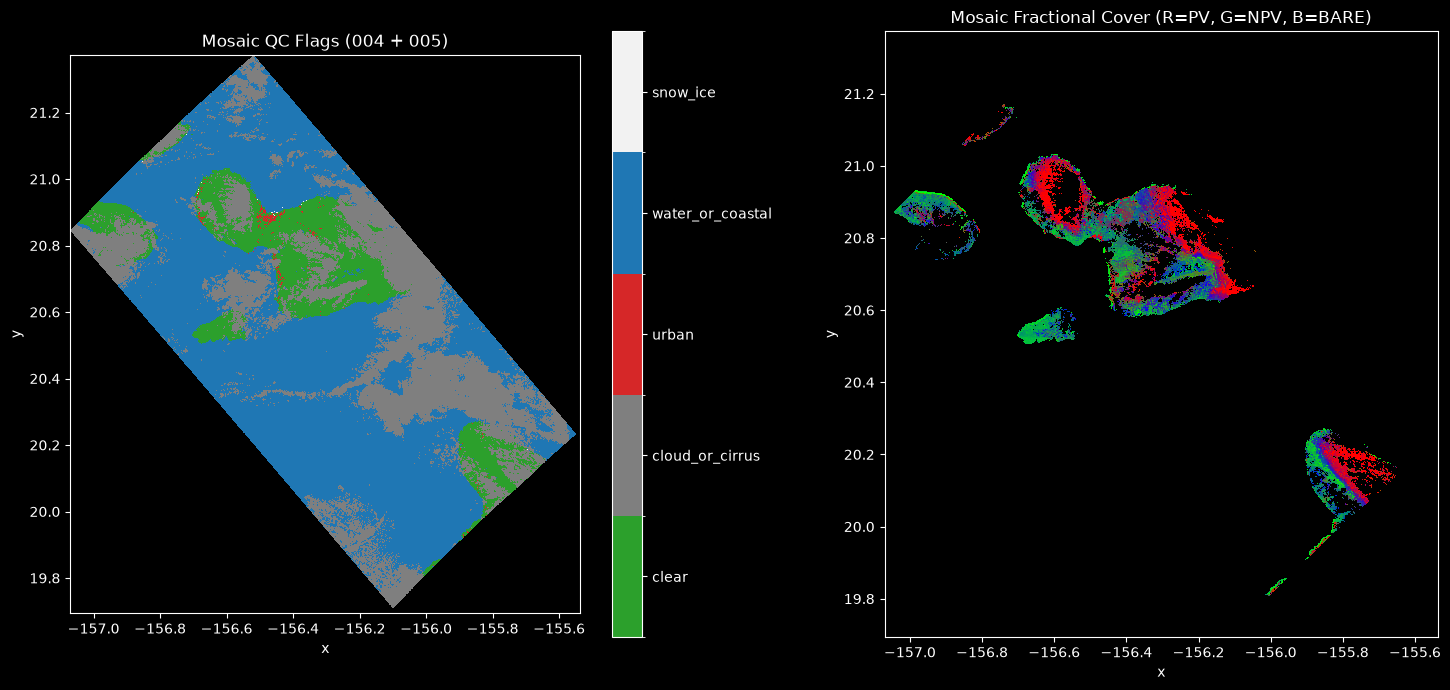

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im0 = ds_mosaic["qc"].plot.imshow(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
axes[0].set_title("Mosaic QC Flags (004 + 005)")
axes[0].set_aspect("equal")
cbar = fig.colorbar(im0, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(list(flag_labels.values()))

rgb_mosaic = xr.concat(
    [ds_mosaic["pv"].fillna(0), ds_mosaic["npv"].fillna(0), ds_mosaic["bare"].fillna(0)],
    dim="band",
).transpose("y", "x", "band")

rgb_mosaic.plot.imshow(ax=axes[1], rgb="band")
axes[1].set_title("Mosaic Fractional Cover (R=PV, G=NPV, B=BARE)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()